## Loading libraries

In [1]:
import numpy as np
import cv2
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
from matplotlib import colors

## Reading the tissue slice

Note that tissue slice is read from the folder [Data to send to Stakeholders for annotating](https://nuwildcat-my.sharepoint.com/my?id=%2Fpersonal%2Fakl0407%5Fads%5Fnorthwestern%5Fedu%2FDocuments%2FSTAT390%2FData%20to%20send%20to%20Stakeholders%20for%20annotating&sortField=LinkFilename&isAscending=true&ga=1).

In [2]:
# Reading tissue slice as RGB
tissue_slice = cv2.cvtColor(cv2.imread("h1849462  h&e_ROI_3.tif"), cv2.COLOR_BGR2RGB)

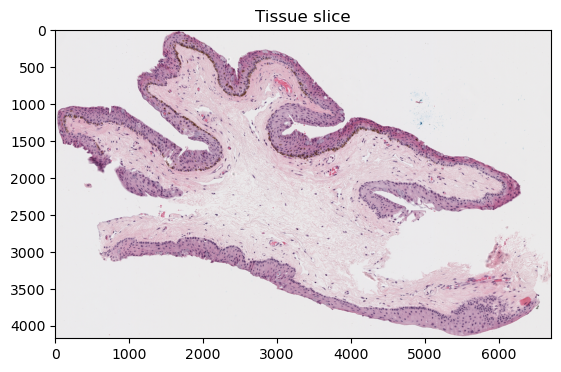

In [3]:
# Checking if the image was read correctly
plt.imshow(tissue_slice);
plt.title("Tissue slice");

## Reading the epithelium mask

Epithelium mask is read from the folder [Annotated slices](https://nuwildcat-my.sharepoint.com/my?id=%2Fpersonal%2Fakl0407%5Fads%5Fnorthwestern%5Fedu%2FDocuments%2FSTAT390%2FAnnotated%5Fslices&sortField=LinkFilename&isAscending=true&ga=1).

In [4]:
# Reading epithelium mask as RGB
epithelium_mask = cv2.cvtColor(cv2.imread("h&e_benign_case85_match1.png"), cv2.COLOR_BGR2RGB)

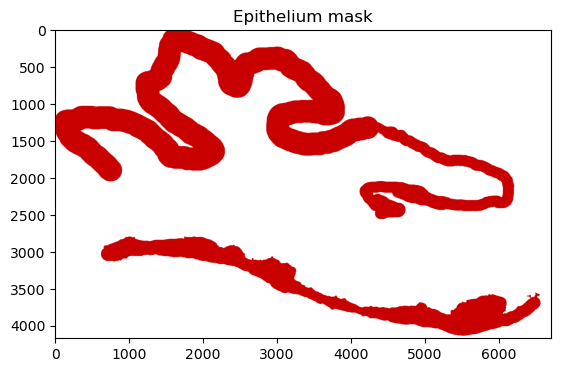

In [5]:
# Checking if the epithelium mask was read correctly
plt.imshow(epithelium_mask);
plt.title("Epithelium mask");

In [6]:
# Checking the shape of the epithelium mask
epithelium_mask.shape

(4168, 6712, 3)

The epithelium mask needs to be have 2D shape for the following reasons:
1. We just want to know if the epithelium is present or not at a pixel coordinate. 
2. The `cv2` function `findContours`, which will be used the find the contours of the above mask needs to have a 2D array as input.

So, we'll convert the epithelium mask to a 2D array as follows.

In [7]:
# Convert the epithelium mask to grayscale to convert it to a 2D array
epithelium_mask_gray = cv2.cvtColor(epithelium_mask, cv2.COLOR_RGB2GRAY)

In [8]:
# Checking if the epithelium mask in grayscale is 2D
epithelium_mask_gray.shape

(4168, 6712)

For finding the contour on the mask, the pixels need to be either 0 or 255. Let us check the pixel values we currently have in the gray epithelium mask.

In [9]:
# Checking the pixel values and their counts in the gray epithelium mask
np.unique(epithelium_mask_gray, return_counts=True)

(array([ 60, 255], dtype=uint8), array([ 5637845, 22337771], dtype=int64))

The pixels aren't 0 and 255. We need to threshold the image using an appropriate threshold, such that all the pixels below the threshold are 0, and above the threshold are 255. Any value between 23 and 255 will be a good threshold for the above image. Finding the thresold manually for each mask will be cumbersome.

Instead of finding the threshold manually, we can use **Otsu's method** to determine the appropriate threshold. Otsu's threshold is the value that classifies the image pixels into two classes by minimizing the variance of pixel values in each of the two classes.

In [10]:
# Using Otsu's threshold to segment the image into a binary image
Otsu_threshold, epithelium_mask_2D = cv2.threshold(epithelium_mask_gray, 0, 255, 
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

In [11]:
# Checking Otsu's threshold
Otsu_threshold

60.0

All pixels with values 60 or below will be reduced to 0.

In [12]:
# Checking the pixel values and their counts in the binary image
# resulting from Otsu's threshold
np.unique(epithelium_mask_2D, return_counts=True)

(array([  0, 255], dtype=uint8), array([22337771,  5637845], dtype=int64))

As desired, the pixels in the 2D epihelium mask are either 0 or 255.

Let us visualize the 2D epithelium mask.

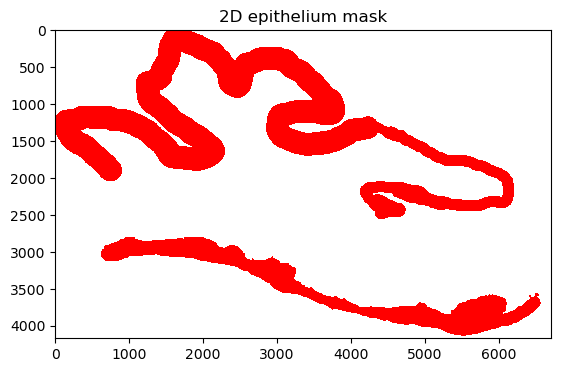

In [13]:
# Checking the epithelium mask
plt.imshow(epithelium_mask_2D, cmap = colors.ListedColormap(['white', 'red']));
plt.title("2D epithelium mask");

## Getting the epithelium contours

In [14]:
# Getting the external contours. There may be multiple external contours
contours, hierarchy = cv2.findContours(epithelium_mask_2D, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

Below is the reasoning behind the arguments used in the function above.

**RETR_EXTERNAL**: If you use this flag, it returns only extreme outer flags. All child contours are left behind

**CHAIN_APPROX_SIMPLE**: If you pass cv.CHAIN_APPROX_NONE, all the boundary points are stored. But actually do we need all the points? For eg, you found the contour of a straight line. Do you need all the points on the line to represent that line? No, we need just two end points of that line. This is what cv.CHAIN_APPROX_SIMPLE does. It removes all redundant points and compresses the contour, thereby saving memory.

In [15]:
# Checking the number of contours
len(contours)

2

We can clearly see there are two different pieces of epithelium, which gives us 2 contours.

Let us visualize the contours.

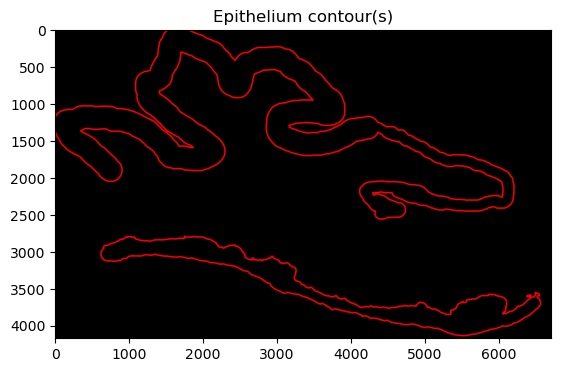

In [16]:
def contour_viz(contour_to_viz, title = ""):    
    # Creating an image as the same size as the epithelium mask
    blank_image = np.zeros_like(epithelium_mask)

    # Drawing contour on the blank image created above
    contour_drawn = cv2.drawContours(blank_image, contour_to_viz, -1, (255, 0, 0), 20)

    # Visualizing the contours
    plt.imshow(contour_drawn);
    plt.title(title);
contour_viz(contours, "Epithelium contour(s)")

## Get normal vectors to contours

### Idea
This section just explains the idea, and need not be executed to get the patches.

Let us consider one of the contours, and see if we can find the tangent at a point on the contour.

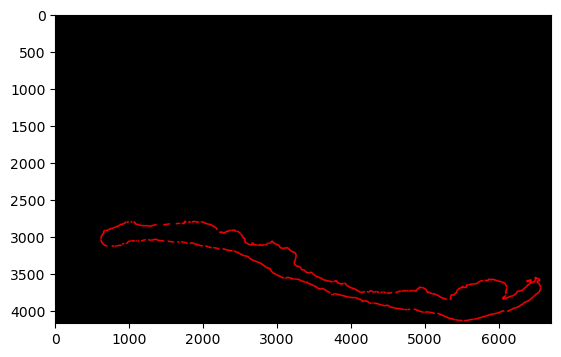

In [17]:
# Considering the first contour
contour = contours[0]

contour_viz(contour);

In [18]:
# Checking the shape of the contour
contour.shape

(4937, 1, 2)

In [19]:
# Checking what the object 'contour' looks like (slicing first 3 rows)
contour[:3]

array([[[1752, 2797]],

       [[1752, 2803]],

       [[1749, 2806]]], dtype=int32)

Note that the contour consists of coordinates of all the points that make the contour. So, to make it less complex, we will convert it to a 3D array.

In [20]:
# Converting contour to a 2D array
contour_points = contour.reshape(-1, 2)

In [21]:
contour_points.shape

(4937, 2)

In [22]:
# Checking what the object 'contour_points' looks like (slicing first 3 rows)
contour_points[:3]

array([[1752, 2797],
       [1752, 2803],
       [1749, 2806]], dtype=int32)

Let us consider the 100th point of the contour, and make a tangent on it.

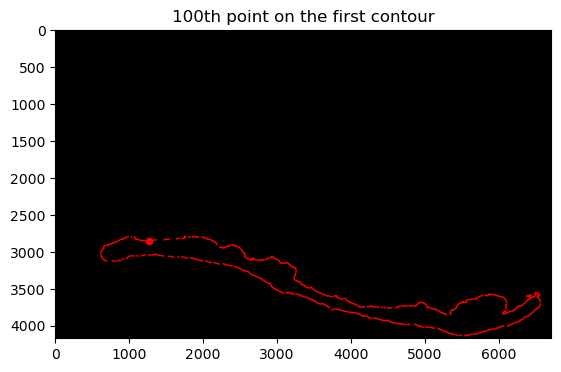

In [23]:
# Considering the 100th point on the contour
i = 100
point = contour_points[i]

# Visualizing the 100th point on the contour
contour_viz(contour, "100th point on the first contour")
plt.scatter(point[0], point[1], color='red', s=20);

We'll approximate the tangent at a point as the line joining the $k^{th}$ point before the 100th point and the $k^{th}$ point after the 100th point. The value of $k$ is a parameter in the algorithm, and can be changed. We are currently calling $k$ as the `smoothing_size`.

#### Visualizing the tangent for `smoothing_size = 50

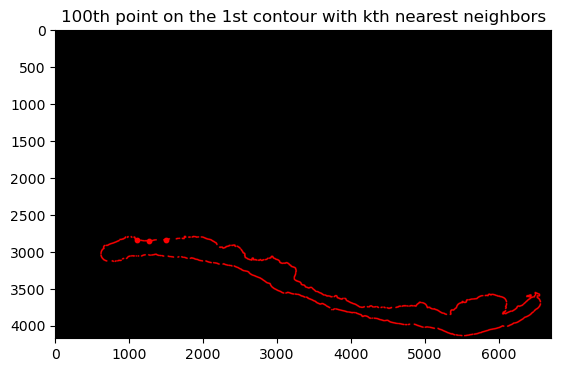

In [24]:
# Assume a value of the parameter 'k' or 'smoothing_size'
smoothing_size = 50

# index of the kth point before the 100th point
prev_idx = (i - smoothing_size)

# index of the kth point after the 100th point
next_idx = (i + smoothing_size)

# Visualizing the 100th point on the contour and its 
# kth neighbors on both sides of the contour
points = [point, contour_points[prev_idx], contour_points[next_idx]]
contour_viz(contour, "100th point on the 1st contour with kth nearest neighbors")
for p in points:
    plt.scatter(p[0], p[1], color='red', s=10);

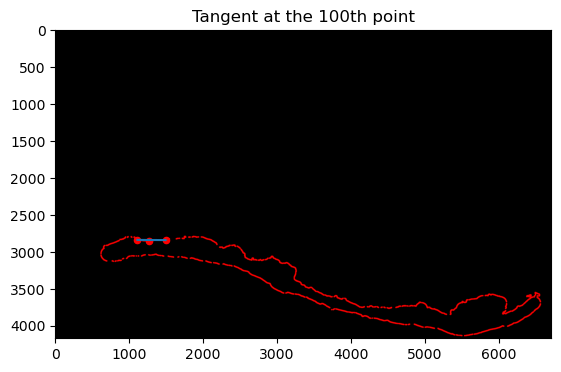

In [25]:
# approximating the tangent at the 100th point as the vector starting
# from the point at 'prev_idx' up to point at 'next_idx'
tangent = contour_points[next_idx] - contour_points[prev_idx]

# Visualizing the points and the tangent vector at the 100th point
contour_viz(contour, "Tangent at the 100th point")
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]]);

#### Visualizing the tangent for `smoothing_size` = 100

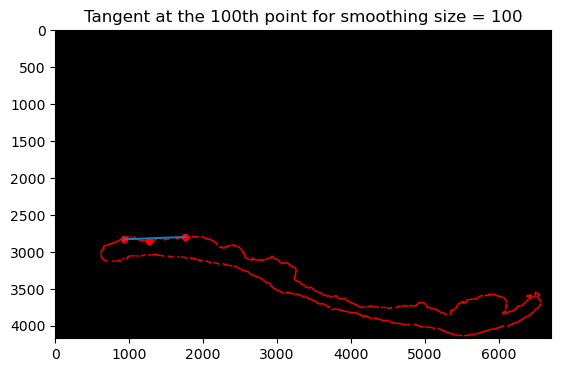

In [26]:
# Assume a value of the parameter 'k' or 'smoothing_size'
smoothing_size = 100

# index of the kth point before the 100th point
prev_idx = (i - smoothing_size)

# index of the kth point after the 100th point
next_idx = (i + smoothing_size)

tangent = contour_points[next_idx] - contour_points[prev_idx]

# Visualizing the points and the tangent vector at the 100th point
contour_viz(contour, "Tangent at the 100th point for smoothing size = 100")
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]]);

#### Visualizing the tangent for `smoothing_size` = 300

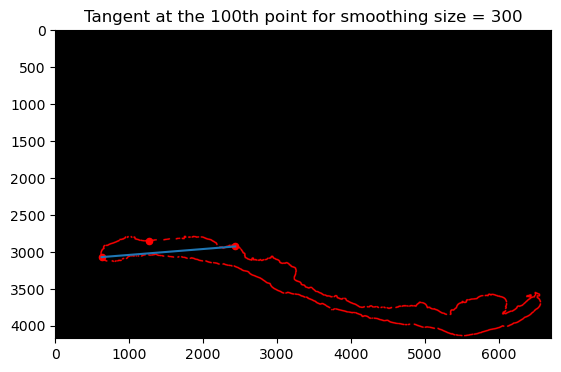

In [27]:
# Assume a value of the parameter 'k' or 'smoothing_size'
smoothing_size = 300

# index of the kth point before the 100th point
prev_idx = (i - smoothing_size)

# index of the kth point after the 100th point
next_idx = (i + smoothing_size)

tangent = contour_points[next_idx] - contour_points[prev_idx]

# Visualizing the points and the tangent vector at the 100th point
contour_viz(contour, "Tangent at the 100th point for smoothing size = 300")
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]]);

As seen in the visualizations above, `smoothing_size` is an imporant parameter as the tangent depends on it. 

**Point to ponder:** Should the algorithm be so sensitive to smoothing size, or does it not matter? How can the algorithm estimate the appropriate value of smoothing size on its own?

We rotate the tangent vector anti-clockwise by 90 degree to get the normal vector. Since the tangent vector moves in an anti-clockwise direction along the contour, the normal vector will always point inside the epithelium.

In [28]:
# Calculating the normal vector perpendicular to the tangent
normal = [-tangent[1], tangent[0]]

### Execution

We implement the idea to calculate the normal over all the points in each of the contours, and store all the normals in the object `all_normals`.

In [139]:
# Initializing 
all_normals=[]
all_tangents = []
smoothing_size = 100

#Loop over all contours in image
for contour in contours:
    #Reshape into xy pairings
    contour_points = contour.reshape(-1,2)
    num_contour_points = len(contour_points)
    tangents = np.zeros_like(contour_points, dtype = float)

    #Calculate tangent using smoothing
    #Higher smoothinng values result in less "jutty" squares, but can work poorly on smaller regions of epithelium
    for i in range(num_contour_points):
        
        # The % operator is used for the case of the index being negative
        prev_idx = (i - smoothing_size) % num_contour_points 
        
        # The % operator is used for the case of the index exceeding bound
        next_idx = (i + smoothing_size) % num_contour_points 
        
        tangent = contour_points[next_idx] - contour_points[prev_idx]
        
        # Normalizing the tangent to unit length, so that the normals will also be of unit length
        # and can be used to estimate epithelium width later
        tangent = tangent / (np.linalg.norm(tangent) + 1e-8)
        tangents[i] = tangent            

    #Convert to normal
    normals = np.zeros_like(tangents)
    normals[:,0] = -tangents[:,1]
    normals[:,1] = tangents[:,0]
    
    #add to list of all contour normals
    all_normals.append(normals)
    all_tangents.append(tangents)

## Estimating epithelium width & patch corners

### Idea: Epithelium width

We will explain the idea to calculate the epithelium width for the same point that was considered earlier, i.e., the $100^{th}$ point of the first contour.

In [30]:
# Considering 100th point on the first contour
i = 100; contour = contours[0]

Height and width of the tissue slice will be used later to identify the pixels along the width of the epithelium, and also to have some idea about the bounds of the epithelium width.

In [31]:
# Height and width of the tissue slice
height, width = epithelium_mask_2D.shape
print("Height of tissue slice:", height)
print("Width of tissue slice:", width)

Height of tissue slice: 4168
Width of tissue slice: 6712


We will define a couple of ad-hoc parameters, whose values have been arbitrary defined as of now:

1. `max_width`: maximum possible width of the epithelium 

2. `step_size`: least count (or precision) of the epithelium width

In [32]:
# Arbitrary values of parameters
max_width = 2048; step_size = 2; smoothing_size = 50

Let us get the co-ordinates of the normal vector at the  $100^{th}$ point.

In [33]:
# Getting coordinates of the normal vector at the 100th point
step_size = 2
steps = np.arange(0, max_width, step_size)[:, None]

# If the points fall outside the slice, they are capped wherever they touch the edge of the slice
normal_points = np.clip(point - steps * all_normals[0][i], 0, [width - 1, height - 1]).astype(int)

We will visualize the normal at the $100^{th}$ point.

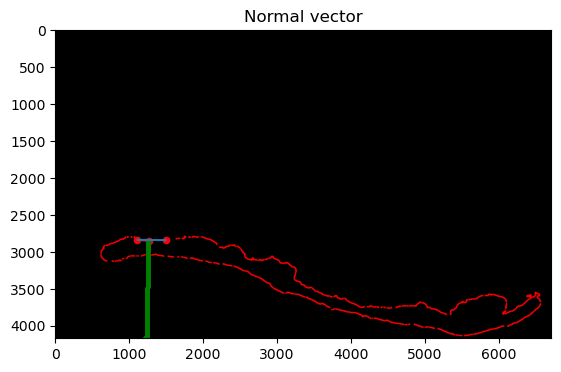

In [34]:
# Visualizing the points and the tangent vector at the 100th point
contour_points = contour.reshape(-1, 2)
prev_idx = (i - smoothing_size)
next_idx = (i + smoothing_size)
contour_viz(contour, "Normal vector")

# Points
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)    
    
# Tangent    
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]]);

# Normal
for p in normal_points:
    plt.scatter(p[0], p[1], color='green', s=3)    

Now, the pixel values on the normal vector will be extracted. Note that the order of pixel values is (y, x) in the images read by `cv2`, while the coordinates of pixels on the normal vector are in the order (x, y)

In [35]:
# extracting pixel values on the normal vector
pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

The pixel values will be 255 along the width of the epithelium, and will become zero as soon as the normal vector extends past the epthithelium width.

In [36]:
# Checking the pixel values
pixel_values

array([255, 255, 255, ...,   0,   0,   0], dtype=uint8)

The epithelium width will be the number of consecutive pixels that are 255.

In [37]:
# finding the first background pixel (where value == 0)
stop = np.where(pixel_values == 0)[0]

# computing epithelium width
epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

Let us check if the correct epthithelium width was found.

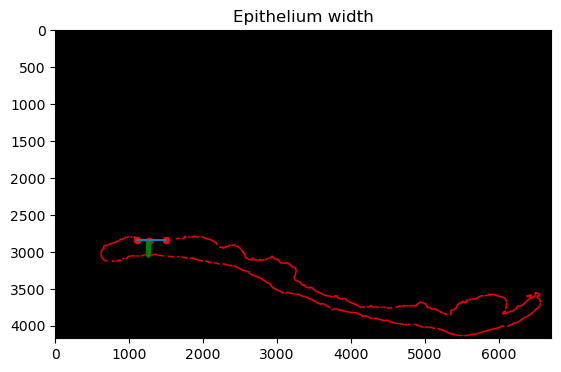

In [38]:
# Visualizing the epithelium width at the 100th point of the 1st contour
contour_viz(contour, "Epithelium width")

# Points
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)    
    
# Tangent    
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]]);

# Epithelium width
for p in normal_points[:int(epithelium_width / step_size)]:
    plt.scatter(p[0], p[1], color='green', s=3)    

### Idea: Patch corners

The patch edge length will be slightly higher than the epithelium width to include a bit of stroma in the patch. The parameter `extension_factor` has been assigned an ad-hoc value of 1.1 to extend the epithelium with by 10% and have it as the patch edge length.

In [39]:
# Ad-hoc value of 'extension_factor'
extension_factor = 1.1

The patch length is obtained as 110% of the epithelium width.

In [40]:
# computing patch length and adjust for stroma extension
patch_length = int(epithelium_width * extension_factor)

The patch will be a square with edges along the tangent and the normal vector. The end-point of the edges will be the patch corners. 

In [41]:
all_tangents[0][i]

array([-0.99978306, -0.02082881])

In [42]:
all_normals[0][i]

array([ 0.02082881, -0.99978306])

In [43]:
patch_length

209

In [44]:
# Half patch length
half_patch_length = patch_length // 2

# Patch corners
corners = np.array([
        point + (all_tangents[0][i] * half_patch_length),
        point - (all_tangents[0][i] * half_patch_length),
        point - (all_tangents[0][i] * half_patch_length) - (all_normals[0][i] * patch_length),
        point + (all_tangents[0][i] * half_patch_length) - (all_normals[0][i] * patch_length)
    ])

Let us visualize the patch corners.

In [45]:
corners

array([[1158.02256211, 2854.83380338],
       [1365.97743789, 2859.16619662],
       [1361.62421583, 3068.12085546],
       [1153.66934005, 3063.78846221]])

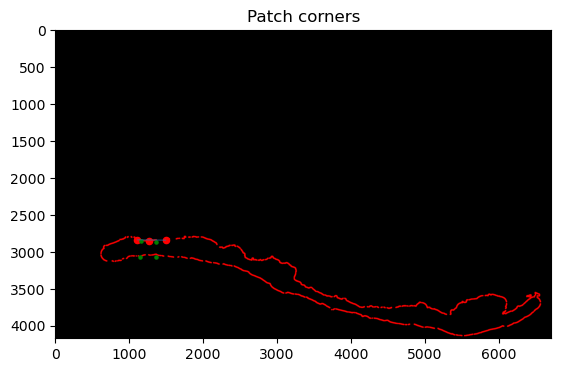

In [46]:
# Visualizing the patch corners
contour_points = contour.reshape(-1, 2)
prev_idx = (i - smoothing_size)
next_idx = (i + smoothing_size)
contour_viz(contour, "Patch corners")

# Points
points_to_plot = [point, contour_points[prev_idx], contour_points[next_idx]]
for p in points_to_plot:
    plt.scatter(p[0], p[1], color='red', s=20)    
    
# Tangent    
plt.plot([contour_points[prev_idx, 0], contour_points[next_idx, 0]],
            [contour_points[prev_idx, 1], contour_points[next_idx, 1]], 
        linewidth=0.5);

# Patch corners
for p in corners.astype(int):
    plt.scatter(p[0], p[1], color='green', s=5)    

### Execution

We'll execute the above idea for all the contour points of each contour.

In [147]:
all_patches = []
all_patch_lengths = []
height, width = epithelium_mask_2D.shape
extension_factor = 1.1; step_size = 2; max_width = 2048

for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
    contour_normals = all_normals[c]
    contour_tangents = all_tangents[c]
    contour_patch_lengths = []
    squares = []
    
    for i, point in enumerate(contour_points):
        point = point.astype(int)

        # generating forward and backward points along the normal
        steps = np.arange(0, max_width, step_size)[:, None]
        normal_points = np.clip(point - steps * contour_normals[i], 0, [width - 1, height - 1]).astype(int)

        # extracting pixel values along the normal path
        pixel_values = epithelium_mask_2D[normal_points[:, 1], normal_points[:, 0]]

        # finding the first background pixel (where value == 0)
        stop = np.where(pixel_values == 0)[0]

        # computing distances
        epithelium_width = stop[0] * step_size if stop.size > 0 else max_width

        # computing total epithelium width and adjust for stroma extension
        patch_length = int(epithelium_width * extension_factor)
        half_patch_length = patch_length // 2 

        # defining square corners 
        corners = np.array([
            point + (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length),
            point - (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length),
            point + (contour_tangents[i] * half_patch_length) - (contour_normals[i] * patch_length)
        ])
        squares.append(corners)
        contour_patch_lengths.append(patch_length)
    all_patches.append(squares)
    all_patch_lengths.append(contour_patch_lengths)

## All patches

Let us use the all the patch corners obtained to visualize the patches. Note that the patches have been created at every pixel of the contour, and so there is likely to be a lot of overlap.

In [141]:
# Function to draw patches
def draw_patches(image, patch_list, color = [255,0,0], thickness = 20):
    patches_on_slice = image.copy()
    for contour_patches in patch_list:
        for patch in contour_patches:
            points = patch.astype(np.int32)
            cv2.polylines(patches_on_slice, [points], isClosed = True, color = color, thickness = thickness)        
    return patches_on_slice

In [142]:
patches_on_slice = draw_patches(tissue_slice, all_patches)

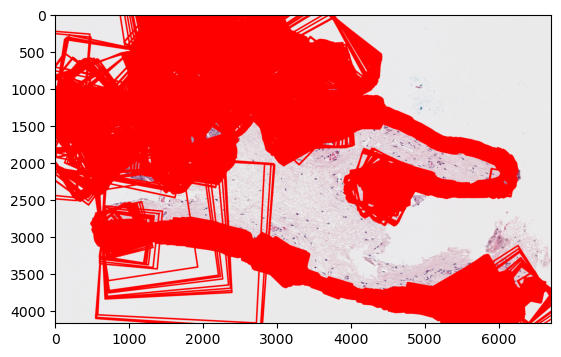

In [143]:
plt.imshow(patches_on_slice);

As seen above, there is a lot of redundancy in patches, so we'll remove patches with a lot of overlap.

## Removing redundant patches
We'll remove patches that have a large overlap with another patch. Here we have another parameter called `overlap_threshold` to control the patch overlap. Its value is arbitrarily chosen to be 0.3.

In [148]:
overlap_threshold = 0.3

In [149]:
def patch_overlap(square1,square2):

    square1 = Polygon(square1)
    square2 = Polygon(square2)

    if not square1.intersects(square2):
        return 0
    
    intersection_area = square1.intersection(square2).area
    smallest_area = min(square1.area,square2.area)
    return intersection_area/smallest_area

In [150]:
all_selected_patches = []
all_selected_patch_lengths = []
for c in range(len(contours)):
    contour_points = contours[c].reshape(-1, 2)
   
    selected_patches = []
    selected_patch_lengths = []
    for i, point in enumerate(contour_points):
        current_patch = all_patches[c][i]
        current_patch_length = all_patch_lengths[c][i]
        if not any(patch_overlap(current_patch, ith_selected_patch) > overlap_threshold \
                 for ith_selected_patch in selected_patches):
            selected_patches.append(current_patch)
            selected_patch_lengths.append(current_patch_length)
    all_selected_patches.append(selected_patches)
    all_selected_patch_lengths.append(selected_patch_lengths)

## Selected patches

In [151]:
selected_patches_on_slice = draw_patches(tissue_slice, all_selected_patches)

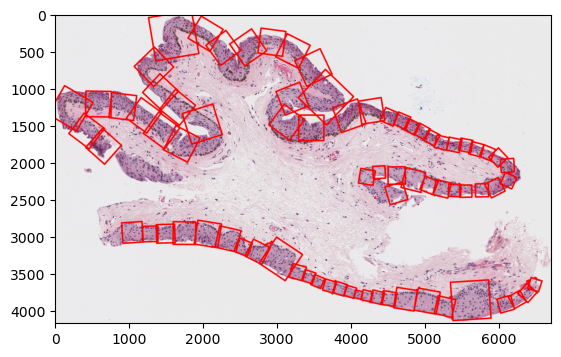

In [152]:
plt.imshow(selected_patches_on_slice);

In [386]:
cv2.imwrite("selected_patches_on_slice.png", cv2.cvtColor(selected_patches_on_slice, cv2.COLOR_RGB2BGR))

True

## Patch evaluation

In [114]:
total_epithelium_pixels = (epithelium_mask_2D > 0).sum()
patch_mask = np.zeros_like(epithelium_mask_2D, dtype=np.uint8)

weight_epithelium_coverage = 0.8
weight_background_pixels = 0.2

#For all patches in all contours, use them to create a mask
for contour_patches in all_selected_patches:
    for patch in contour_patches:
        patch = np.array(patch,dtype = np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(patch_mask, [patch], 255)

number_of_patch_mask_pixels = np.count_nonzero(patch_mask > 0)

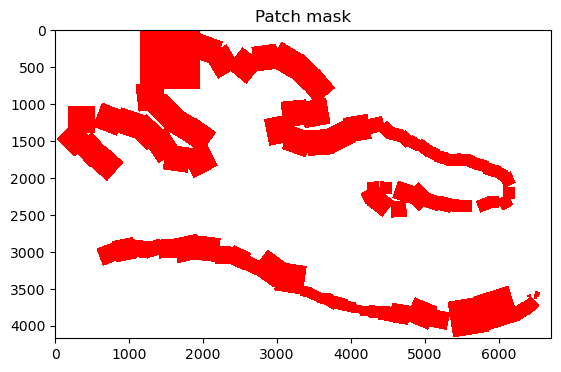

In [115]:
# Checking the patch mask
plt.imshow(patch_mask, cmap = colors.ListedColormap(['white', 'red']));
plt.title("Patch mask");

In [116]:
covered_epithelium_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D > 0))
covered_background_pixels = np.count_nonzero((patch_mask > 0) & (epithelium_mask_2D == 0))

total_epithelium_coverage = (covered_epithelium_pixels / total_epithelium_pixels*100)
background_pixel_percent = (covered_background_pixels / number_of_patch_mask_pixels*100)
score = weight_epithelium_coverage*total_epithelium_coverage + weight_background_pixels*(100 - background_pixel_percent)

